# 셀 2. import 및 기본 설정

In [1]:
import os
import io
import json
import time
from datetime import datetime
from pathlib import Path
from typing import List, Optional

import cv2
import numpy as np
import pandas as pd
import requests
from PIL import Image
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from google import genai
from google.genai import types

# 셀 3. .env에서 Gemini API Key 불러오기

In [3]:
load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "🚨 GEMINI_API_KEY를 찾을 수 없습니다. "
        ".env 파일에 GEMINI_API_KEY=본인키 형식으로 저장했는지 확인해주세요."
    )

client = genai.Client(api_key=GEMINI_API_KEY)

print("✅ Gemini client 연결 완료")

✅ Gemini client 연결 완료


# 셀 4. 경로 설정

In [4]:
PROJECT_ROOT = Path.cwd()

INPUT_CSV_PATH = PROJECT_ROOT / "data" / "input" / "shorts-analysis_test-1 copy.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "thumbnails"
RAW_DIR = OUTPUT_DIR / "raw"
JSON_DIR = OUTPUT_DIR / "analysis_json"

CSV_OUTPUT_PATH = OUTPUT_DIR / "thumbnail_features.csv"
PARQUET_OUTPUT_PATH = OUTPUT_DIR / "thumbnail_features.parquet"
LOG_PATH = OUTPUT_DIR / "processing_log.csv"

RAW_DIR.mkdir(parents=True, exist_ok=True)
JSON_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_CSV_PATH:", INPUT_CSV_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_image
INPUT_CSV_PATH: c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_image\data\input\shorts-analysis_test-1 copy.csv
OUTPUT_DIR: c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_image\data\thumbnails


# 셀 5. 모델 및 실행 옵션 설정

In [ ]:
MODEL_NAME = "gemini-2.5-flash"

PROMPT_VERSION = "v1"
SCHEMA_VERSION = "v1"

MAX_RETRIES = 1
REQUEST_SLEEP_SECONDS = 0.5

print("MODEL_NAME:", MODEL_NAME)

MODEL_NAME: gemini-2.5-flash


# 셀 6. Gemini 출력 스키마 정의

In [6]:
class ThumbnailGeminiResult(BaseModel):
    visual_summary: str = Field(description="썸네일 전체 장면을 한국어 1문장으로 요약")
    main_objects: List[str] = Field(description="주요 객체 리스트. 예: person, product, text, brand_logo")

    thumbnail_category: str = Field(
        description="정보전달형, 제품홍보형, 브랜드이미지형, 이벤트홍보형, 인터뷰/인물형, 리뷰/비교형, 기타 중 하나"
    )

    has_person: bool
    person_count: int
    has_face: bool
    facial_expression: str = Field(description="smile, neutral, serious, surprised, unclear, none 등")

    has_text: bool
    text_on_thumbnail: str = Field(description="이미지 안에 보이는 문구. 없으면 빈 문자열")
    text_language: str = Field(description="ko, en, mixed, none, unknown 등")
    text_size_level: str = Field(description="none, small, medium, large 중 하나")

    brand_logo_visible: bool
    brand_name_visible: bool
    brand_name_detected: str = Field(description="감지된 브랜드명. 불확실하면 빈 문자열")

    dominant_colors: List[str] = Field(description="주요 색상 리스트. 예: blue, white, black")
    color_tone: str = Field(description="warm, cool, neutral 중 하나")
    background_complexity: str = Field(description="low, medium, high 중 하나")

    composition_style: str = Field(
        description="person_centered, product_centered, text_centered, mixed, other 중 하나"
    )
    attention_hook: str = Field(description="클릭을 유도하는 핵심 시각 요소를 한국어 1문장으로 설명")

    clickbait_level: int = Field(description="자극성/낚시성 정도. 0~5 정수")
    professional_level: int = Field(description="기업 유튜브 썸네일로서의 완성도. 0~5 정수")

    target_audience_guess: str = Field(description="예상 타겟 시청자. 예: general_consumers, job_seekers, investors 등")

# 셀 7. 프롬프트 정의

In [7]:
THUMBNAIL_PROMPT = """
너는 기업 유튜브 썸네일 분석 전문가다.
입력된 유튜브 썸네일 이미지를 보고 기업 유튜브 관점에서 시각적 특징을 분석하라.

분석 원칙:
1. 기업 공식 채널 또는 브랜드 채널의 썸네일이라고 가정하고 평가한다.
2. 썸네일의 인물, 제품, 텍스트, 브랜드 로고, 색감, 구도, 클릭 유도 요소를 분석한다.
3. 불확실한 내용은 과도하게 단정하지 않는다.
4. clickbait_level은 자극성/낚시성 정도를 0~5 정수로 평가한다.
   - 0: 전혀 자극적이지 않음
   - 1: 매우 약함
   - 2: 약간 있음
   - 3: 보통
   - 4: 강함
   - 5: 매우 강함
5. professional_level은 기업 유튜브 썸네일로서의 완성도를 0~5 정수로 평가한다.
   - 0: 매우 낮음
   - 1: 낮음
   - 2: 다소 낮음
   - 3: 보통
   - 4: 높음
   - 5: 매우 높음
6. thumbnail_category는 반드시 아래 중 하나로 분류한다.
   - 정보전달형
   - 제품홍보형
   - 브랜드이미지형
   - 이벤트홍보형
   - 인터뷰/인물형
   - 리뷰/비교형
   - 기타
7. composition_style은 반드시 아래 중 하나로 분류한다.
   - person_centered
   - product_centered
   - text_centered
   - mixed
   - other
8. background_complexity는 low / medium / high 중 하나로 분류한다.
9. text_size_level은 none / small / medium / large 중 하나로 분류한다.
10. color_tone은 warm / cool / neutral 중 하나로 분류한다.
"""

# 셀 8. 입력 CSV 불러오기 함수

In [8]:
def load_input_csv(input_csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(input_csv_path)

    if "video_id" not in df.columns:
        raise ValueError("입력 CSV에 video_id 컬럼이 필요합니다.")

    df["video_id"] = df["video_id"].astype(str).str.strip()
    df = df[df["video_id"].notna()]
    df = df[df["video_id"] != ""]
    df = df.drop_duplicates(subset=["video_id"])

    return df

In [9]:
# 테스트
input_df = load_input_csv(INPUT_CSV_PATH)

print(input_df.shape)
input_df.head()

(6, 26)


,Unnamed: 0,video_id,title,channel_id,channel_title,description,upload_date,tags,category_id,view_count,...,has_paid_product_placement,thumbnail,thumbnail_h,thumbnail_w,caption,year,verdict,reasoning,final_url,domain
0,1630,knCQBlBKSRM,[B 다이렉트샵] 필사즉생의 각오로 임하는 발음 연습,UCwR9k7QggFEfeHkvTR31JcA,SK브로드밴드_B tv,죽고자 하면 산다고 하잖아요\n그래서 죽기살기로 연습해달라 했죠.\n그렇게 하다보니...,2026-02-13 04:20:50+00:00,NaN,1,3615612,...,False,https://i.ytimg.com/vi/knCQBlBKSRM/hqdefault.jpg,360,480,False,2026,shorts,kept /shorts route,https://www.youtube.com/shorts/knCQBlBKSRM,IT
1,1631,NCVxpXxTMSU,[B 다이렉트샵] 고음불가? NO! 발음불가? YES,UCwR9k7QggFEfeHkvTR31JcA,SK브로드밴드_B tv,연습 50일 째. 광고주 담당자 얼굴에서\n안색이라는 것이 점차 사라져가고 있습니다...,2026-02-13 04:20:46+00:00,NaN,1,3041416,...,False,https://i.ytimg.com/vi/NCVxpXxTMSU/hqdefault.jpg,360,480,False,2026,shorts,kept /shorts route,https://www.youtube.com/shorts/NCVxpXxTMSU,IT
2,1640,LRmLOsmMHts,에이닷과 대화하며 즐기는 B tv IPTV로 바꾸자! (문의 1600-2345),UCwR9k7QggFEfeHkvTR31JcA,SK브로드밴드_B tv,아직도 IPTV로 안 바꾸셨어요?\n\n주인공이 뛰는 미국 영화가 뭐였더라?\n궁금...,2026-01-08 07:58:00+00:00,NaN,1,261176,...,False,https://i.ytimg.com/vi/LRmLOsmMHts/hqdefault.jpg,360,480,False,2026,shorts,kept /shorts route,https://www.youtube.com/shorts/LRmLOsmMHts,IT
3,655,twi9zUxsXu0,🍓 + 🍫 +🌽 + 🥘 = 😋 | CU X 프롬서희 이모티콘 먹방 2월 3주차 #...,UCsM07dUwo0WOWhFbVsG8K6A,CU [씨유튜브],이렇게 귀엽기 잇씨유? (✿◡‿◡)\n\n귀여운 꽃카 콜라보 신상과\n한국인은 못참...,2023-02-15 09:00:18+00:00,"먹방, MUKBANG, mukbang, 이모지먹방, 이모티콘먹방, emoji, em...",24,189406,...,False,https://i.ytimg.com/vi/twi9zUxsXu0/hqdefault.jpg,360,480,False,2023,shorts,kept /shorts route,https://www.youtube.com/shorts/twi9zUxsXu0,FnB
4,656,Xfu1kCID0Ls,[연예뉴스] 두 아티스트의 불화설이 제기돼... | CU콘서트 #4강 #B조 #3라운드,UCsM07dUwo0WOWhFbVsG8K6A,CU [씨유튜브],스탠딩 코미디의 부활! [CU콘서트]\n\nCU 공채 개그맨에 한 걸음 더 다가선\...,2023-02-13 09:00:40+00:00,"CU편의점, CU, 씨유, 헤이루, Heyroo, cu콘서트, cuconcert, ...",24,46925,...,False,https://i.ytimg.com/vi/Xfu1kCID0Ls/hqdefault.jpg,360,480,False,2023,shorts,kept /shorts route,https://www.youtube.com/shorts/Xfu1kCID0Ls,FnB


# 셀 9. 썸네일 URL 생성 및 다운로드 함수

In [10]:
def build_thumbnail_url(video_id: str) -> str:
    return f"https://img.youtube.com/vi/{video_id}/hqdefault.jpg"


def download_thumbnail(video_id: str, thumbnail_url: str) -> str:
    save_path = RAW_DIR / f"{video_id}.jpg"

    # 이미 다운로드한 파일이 있으면 재사용
    if save_path.exists() and save_path.stat().st_size > 1000:
        return str(save_path)

    response = requests.get(thumbnail_url, timeout=15)
    response.raise_for_status()

    if len(response.content) < 1000:
        raise ValueError("다운로드된 이미지 용량이 너무 작습니다.")

    with open(save_path, "wb") as f:
        f.write(response.content)

    return str(save_path)

knCQBlBKSRM
https://img.youtube.com/vi/knCQBlBKSRM/hqdefault.jpg
c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_image\data\thumbnails\raw\knCQBlBKSRM.jpg


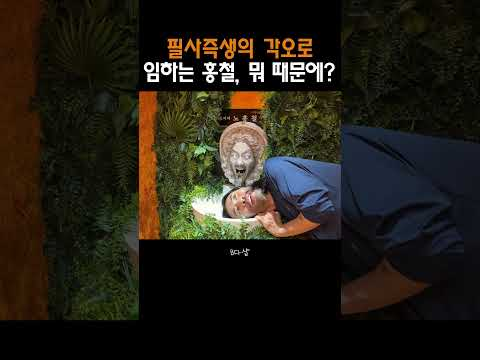

In [11]:
# 테스트
test_video_id = input_df.iloc[0]["video_id"]
test_url = build_thumbnail_url(test_video_id)
test_path = download_thumbnail(test_video_id, test_url)

print(test_video_id)
print(test_url)
print(test_path)

Image.open(test_path)

# 셀 10. OpenCV 정량 특징 추출 함수

In [12]:
def extract_opencv_features(image_path: str) -> dict:
    image = cv2.imread(image_path)

    if image is None:
        raise ValueError("OpenCV가 이미지를 읽지 못했습니다.")

    height, width = image.shape[:2]

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness_mean = float(np.mean(hsv[:, :, 2]))
    saturation_mean = float(np.mean(hsv[:, :, 1]))
    contrast_std = float(np.std(gray))

    aspect_ratio_value = width / height if height else None

    if aspect_ratio_value is not None:
        if abs(aspect_ratio_value - 16 / 9) < 0.05:
            aspect_ratio = "16:9"
        elif abs(aspect_ratio_value - 4 / 3) < 0.05:
            aspect_ratio = "4:3"
        elif abs(aspect_ratio_value - 1) < 0.05:
            aspect_ratio = "1:1"
        elif aspect_ratio_value < 1:
            aspect_ratio = "vertical"
        else:
            aspect_ratio = "other"
    else:
        aspect_ratio = "unknown"

    return {
        "image_width": int(width),
        "image_height": int(height),
        "aspect_ratio": aspect_ratio,
        "brightness_mean": round(brightness_mean, 2),
        "contrast_std": round(contrast_std, 2),
        "saturation_mean": round(saturation_mean, 2),
    }

In [13]:
# 테스트
opencv_features = extract_opencv_features(test_path)
opencv_features

{'image_width': 480,
 'image_height': 360,
 'aspect_ratio': '4:3',
 'brightness_mean': 38.2,
 'contrast_std': 43.13,
 'saturation_mean': 111.33}

# 셀 11. Gemini 분석 함수

In [ ]:
def analyze_thumbnail_with_gemini(image_path: str, max_retries: int = 5) -> dict:
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    last_error = None

    for attempt in range(1, max_retries + 1):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=[
                    types.Part.from_bytes(
                        data=image_bytes,
                        mime_type="image/jpeg",
                    ),
                    THUMBNAIL_PROMPT,
                ],
                config=types.GenerateContentConfig(
                    temperature=0.2,
                    response_mime_type="application/json",
                    response_schema=ThumbnailGeminiResult,
                ),
            )

            return json.loads(response.text)

        except Exception as e:
            last_error = e
            print(f"⚠️ Gemini 호출 실패 attempt={attempt}/{max_retries}: {e}")

            if attempt < max_retries:
                wait_seconds = 2 ** attempt
                print(f"   {wait_seconds}초 후 재시도합니다.")
                time.sleep(wait_seconds)

    raise last_error

In [15]:
gemini_features = analyze_thumbnail_with_gemini(test_path)
gemini_features

⚠️ Gemini 호출 실패 attempt=1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   2초 후 재시도합니다.
⚠️ Gemini 호출 실패 attempt=2/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   4초 후 재시도합니다.


{'visual_summary': "한 남자가 잎이 무성한 배경과 석상 아래에 누워있고, 상단에는 '필사즉생의 각오로 임하는 홍철, 뭐 때문에?'라는 문구가 적혀있다.",
 'main_objects': ['person', 'text', 'sculpture', 'plant'],
 'thumbnail_category': '인터뷰/인물형',
 'has_person': True,
 'person_count': 1,
 'has_face': True,
 'facial_expression': 'surprised',
 'has_text': True,
 'text_on_thumbnail': '필사즉생의 각오로 임하는 홍철, 뭐 때문에? 딴날',
 'text_language': 'ko',
 'text_size_level': 'large',
 'brand_logo_visible': False,
 'brand_name_visible': False,
 'brand_name_detected': '',
 'dominant_colors': ['black', 'green', 'blue', 'white', 'orange'],
 'color_tone': 'warm',
 'background_complexity': 'medium',
 'composition_style': 'person_centered',
 'attention_hook': "남자가 기이한 석상 아래에 누워있는 독특한 상황과 '필사즉생'이라는 강렬한 문구가 시청자의 궁금증을 유발한다.",
 'clickbait_level': 4,
 'professional_level': 4,
 'target_audience_guess': 'general_consumers'}

# 셀 12. 저장 관련 함수

In [16]:
def save_json_result(video_id: str, result: dict) -> None:
    save_path = JSON_DIR / f"{video_id}.json"

    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)


def append_log(row: dict) -> None:
    log_df = pd.DataFrame([row])

    if LOG_PATH.exists():
        log_df.to_csv(LOG_PATH, mode="a", header=False, index=False, encoding="utf-8-sig")
    else:
        log_df.to_csv(LOG_PATH, index=False, encoding="utf-8-sig")


def flatten_list_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ["main_objects", "dominant_colors"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: "|".join(x) if isinstance(x, list) else x
            )

    return df

# 셀 13. 이미 처리한 video_id 확인 함수

In [17]:
def get_processed_video_ids() -> set:
    processed = set()

    for json_file in JSON_DIR.glob("*.json"):
        processed.add(json_file.stem)

    return processed

In [18]:
# 테스트
processed_ids = get_processed_video_ids()
len(processed_ids)

0

# 셀 14. 영상 1개 처리 함수

In [19]:
def process_one_video(row: pd.Series) -> dict:
    video_id = str(row["video_id"]).strip()

    channel_id = row["channel_id"] if "channel_id" in row.index else ""
    title = row["title"] if "title" in row.index else ""

    thumbnail_url = build_thumbnail_url(video_id)
    processed_at = datetime.now().isoformat(timespec="seconds")

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            thumbnail_path = download_thumbnail(video_id, thumbnail_url)

            opencv_features = extract_opencv_features(thumbnail_path)

            gemini_features = analyze_thumbnail_with_gemini(thumbnail_path)

            result = {
                "video_id": video_id,
                "channel_id": channel_id,
                "title": title,
                "thumbnail_url": thumbnail_url,
                "thumbnail_path": thumbnail_path,

                **opencv_features,
                **gemini_features,

                "analysis_engine": "gemini",
                "analysis_model": MODEL_NAME,
                "prompt_version": PROMPT_VERSION,
                "schema_version": SCHEMA_VERSION,
                "status": "success",
                "error_message": None,
                "processed_at": processed_at,
            }

            save_json_result(video_id, result)

            append_log({
                "video_id": video_id,
                "status": "success",
                "stage": "done",
                "attempt": attempt,
                "error_message": "",
                "processed_at": processed_at,
            })

            return result

        except Exception as e:
            error_message = str(e)

            append_log({
                "video_id": video_id,
                "status": "retrying" if attempt < MAX_RETRIES else "failed",
                "stage": "process_one_video",
                "attempt": attempt,
                "error_message": error_message,
                "processed_at": datetime.now().isoformat(timespec="seconds"),
            })

            print(f"❌ 오류 발생: {video_id} / attempt={attempt} / {error_message}")

            if attempt < MAX_RETRIES:
                time.sleep(2 * attempt)
            else:
                result = {
                    "video_id": video_id,
                    "channel_id": channel_id,
                    "title": title,
                    "thumbnail_url": thumbnail_url,
                    "thumbnail_path": None,
                    "analysis_engine": "gemini",
                    "analysis_model": MODEL_NAME,
                    "prompt_version": PROMPT_VERSION,
                    "schema_version": SCHEMA_VERSION,
                    "status": "failed",
                    "error_message": error_message,
                    "processed_at": datetime.now().isoformat(timespec="seconds"),
                }

                save_json_result(video_id, result)
                return result

In [20]:
# 테스트
test_result = process_one_video(input_df.iloc[0])
test_result

{'video_id': 'knCQBlBKSRM',
 'channel_id': 'UCwR9k7QggFEfeHkvTR31JcA',
 'title': '[B 다이렉트샵] 필사즉생의 각오로 임하는 발음 연습',
 'thumbnail_url': 'https://img.youtube.com/vi/knCQBlBKSRM/hqdefault.jpg',
 'thumbnail_path': 'c:\\Users\\user\\Desktop\\Uk_folder\\sparta_bootcamp\\project_collection\\final_project\\final_project\\works\\Hyeong_Uk\\thumb_image\\data\\thumbnails\\raw\\knCQBlBKSRM.jpg',
 'image_width': 480,
 'image_height': 360,
 'aspect_ratio': '4:3',
 'brightness_mean': 38.2,
 'contrast_std': 43.13,
 'saturation_mean': 111.33,
 'visual_summary': '녹색 식물 배경 앞에 한 남자가 돌 조각상 옆에 누워있고, 상단에는 강렬한 문구의 한국어 텍스트가 쓰여 있습니다.',
 'main_objects': ['person', 'text', 'sculpture', 'plants'],
 'thumbnail_category': '인터뷰/인물형',
 'has_person': True,
 'person_count': 1,
 'has_face': True,
 'facial_expression': 'unclear',
 'has_text': True,
 'text_on_thumbnail': '필사즉생의 각오로 임하는 홍철, 뭐 때문에?딴날',
 'text_language': 'ko',
 'text_size_level': 'large',
 'brand_logo_visible': False,
 'brand_name_visible': False,
 'brand_name_d

# 셀 15. 여러 개 처리 함수

In [21]:
def run_thumbnail_pipeline(
    input_df: pd.DataFrame,
    limit: Optional[int] = 10,
    skip_processed: bool = True,
) -> pd.DataFrame:

    if limit is not None:
        run_df = input_df.head(limit).copy()
    else:
        run_df = input_df.copy()

    processed_video_ids = get_processed_video_ids() if skip_processed else set()

    results = []
    total_count = len(run_df)

    for n, (_, row) in enumerate(run_df.iterrows(), start=1):
        video_id = str(row["video_id"]).strip()

        if skip_processed and video_id in processed_video_ids:
            print(f"[SKIP] 이미 처리됨: {video_id}")
            continue

        print(f"[{n}/{total_count}] 분석 중: {video_id}")

        result = process_one_video(row)
        results.append(result)

        time.sleep(REQUEST_SLEEP_SECONDS)

    if len(results) == 0:
        print("새로 처리된 결과가 없습니다.")
        return pd.DataFrame()

    new_df = pd.DataFrame(results)
    new_df_for_csv = flatten_list_columns(new_df)

    if CSV_OUTPUT_PATH.exists():
        old_df = pd.read_csv(CSV_OUTPUT_PATH)
        combined_df = pd.concat([old_df, new_df_for_csv], ignore_index=True)
        combined_df = combined_df.drop_duplicates(subset=["video_id"], keep="last")
    else:
        combined_df = new_df_for_csv

    combined_df.to_csv(CSV_OUTPUT_PATH, index=False, encoding="utf-8-sig")

    try:
        combined_df.to_parquet(PARQUET_OUTPUT_PATH, index=False)
    except Exception as e:
        print(f"[WARN] parquet 저장 실패: {e}")

    print("✅ 저장 완료")
    print("CSV:", CSV_OUTPUT_PATH)
    print("Parquet:", PARQUET_OUTPUT_PATH)

    return combined_df

# 셀 16. 10개만 테스트 실행

In [ ]:
result_df = run_thumbnail_pipeline(
    input_df=input_df,
    limit=10,
    skip_processed=True,
)

result_df.head(10)

[SKIP] 이미 처리됨: knCQBlBKSRM
[2/6] 분석 중: NCVxpXxTMSU
⚠️ Gemini 호출 실패 attempt=1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   2초 후 재시도합니다.
⚠️ Gemini 호출 실패 attempt=2/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   4초 후 재시도합니다.
[3/6] 분석 중: LRmLOsmMHts
[4/6] 분석 중: twi9zUxsXu0
⚠️ Gemini 호출 실패 attempt=1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
   2초 후 재시도합니다.
[5/6] 분석 중: Xfu1kCID0Ls
[6/6] 분석 중: MIJR3Dm0YOk
✅ 저장 완료
CSV: c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_ima

,video_id,channel_id,title,thumbnail_url,thumbnail_path,image_width,image_height,aspect_ratio,brightness_mean,contrast_std,...,clickbait_level,professional_level,target_audience_guess,analysis_engine,analysis_model,prompt_version,schema_version,status,error_message,processed_at
0,NCVxpXxTMSU,UCwR9k7QggFEfeHkvTR31JcA,[B 다이렉트샵] 고음불가? NO! 발음불가? YES,https://img.youtube.com/vi/NCVxpXxTMSU/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,45.45,52.26,...,3,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,None,2026-04-29T19:33:15
1,LRmLOsmMHts,UCwR9k7QggFEfeHkvTR31JcA,에이닷과 대화하며 즐기는 B tv IPTV로 바꾸자! (문의 1600-2345),https://img.youtube.com/vi/LRmLOsmMHts/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,104.34,95.12,...,2,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,None,2026-04-29T19:33:51
2,twi9zUxsXu0,UCsM07dUwo0WOWhFbVsG8K6A,🍓 + 🍫 +🌽 + 🥘 = 😋 | CU X 프롬서희 이모티콘 먹방 2월 3주차 #...,https://img.youtube.com/vi/twi9zUxsXu0/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,83.47,66.09,...,1,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,None,2026-04-29T19:34:02
3,Xfu1kCID0Ls,UCsM07dUwo0WOWhFbVsG8K6A,[연예뉴스] 두 아티스트의 불화설이 제기돼... | CU콘서트 #4강 #B조 #3라운드,https://img.youtube.com/vi/Xfu1kCID0Ls/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,7.59,26.49,...,2,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,None,2026-04-29T19:34:19
4,MIJR3Dm0YOk,UCsM07dUwo0WOWhFbVsG8K6A,학부모 참관수업에서 당황한 이유 | CU콘서트 #4강 #B조 #3라운드,https://img.youtube.com/vi/MIJR3Dm0YOk/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,17.09,37.71,...,3,5,"general_consumers, music_fans",gemini,gemini-2.5-flash,v1,v1,success,None,2026-04-29T19:34:29


# 셀 17. 결과 확인

In [ ]:
if result_df.empty:
    print("이번 실행에서 새로 처리된 결과가 없습니다.")
    thumbnail_df = rebuild_csv_from_json()
else:
    thumbnail_df = result_df.copy()

check_cols = [
    "video_id",
    "thumbnail_category",
    "has_person",
    "has_text",
    "text_on_thumbnail",
    "brand_logo_visible",
    "clickbait_level",
    "professional_level",
    "brightness_mean",
    "contrast_std",
    "saturation_mean",
    "status",
]

existing_cols = [col for col in check_cols if col in thumbnail_df.columns]

display(thumbnail_df[existing_cols].head(20))

,video_id,thumbnail_category,has_person,has_text,text_on_thumbnail,brand_logo_visible,clickbait_level,professional_level,brightness_mean,contrast_std,saturation_mean,status
0,NCVxpXxTMSU,정보전달형,True,True,노홍철은 고음불가? NO! 발음불가? YES!! B나이다 흥정마시어~,False,3,4,45.45,52.26,75.42,success
1,LRmLOsmMHts,제품홍보형,True,True,에이닷과 대화하며 즐기는 Btv로 바꾸자 특별한 혜택까지!,True,2,4,104.34,95.12,55.46,success
2,twi9zUxsXu0,제품홍보형,True,True,HEYROO POPCORN 대파콘소메맛 팝콘,True,1,4,83.47,66.09,76.01,success
3,Xfu1kCID0Ls,인터뷰/인물형,True,True,CU 콘서트 4강 정승환 VS 이무진 대환장 콜라보 아버지는~♪,True,2,4,7.59,26.49,13.64,success
4,MIJR3Dm0YOk,인터뷰/인물형,True,True,CU 콘서트 4차 정승환 VS 이무진 반전의 반전의 반전 누가,True,3,5,17.09,37.71,18.23,success


# 셀 18. 저장된 JSON 하나 확인

In [ ]:
thumbnail_df = rebuild_csv_from_json()

if thumbnail_df.empty:
    print("확인할 JSON 결과가 없습니다.")
else:
    sample_video_id = thumbnail_df.iloc[0]["video_id"]
    sample_json_path = JSON_DIR / f"{sample_video_id}.json"

    with open(sample_json_path, "r", encoding="utf-8") as f:
        sample_json = json.load(f)

    display(sample_json)

{'video_id': 'NCVxpXxTMSU',
 'channel_id': 'UCwR9k7QggFEfeHkvTR31JcA',
 'title': '[B 다이렉트샵] 고음불가? NO! 발음불가? YES',
 'thumbnail_url': 'https://img.youtube.com/vi/NCVxpXxTMSU/hqdefault.jpg',
 'thumbnail_path': 'c:\\Users\\user\\Desktop\\Uk_folder\\sparta_bootcamp\\project_collection\\final_project\\final_project\\works\\Hyeong_Uk\\thumb_image\\data\\thumbnails\\raw\\NCVxpXxTMSU.jpg',
 'image_width': 480,
 'image_height': 360,
 'aspect_ratio': '4:3',
 'brightness_mean': 45.45,
 'contrast_std': 52.26,
 'saturation_mean': 75.42,
 'visual_summary': "한 사람이 거대한 황금 마스크를 올려다보고 있으며, 그 위에 '노홍철은 고음불가? NO! 발음불가? YES!!'라는 문구가 쓰여 있다.",
 'main_objects': ['person', 'text', 'mask', 'bookshelf'],
 'thumbnail_category': '정보전달형',
 'has_person': True,
 'person_count': 1,
 'has_face': True,
 'facial_expression': 'surprised',
 'has_text': True,
 'text_on_thumbnail': '노홍철은 고음불가? NO! 발음불가? YES!! B나이다 흥정마시어~',
 'text_language': 'ko',
 'text_size_level': 'large',
 'brand_logo_visible': False,
 'brand_name_visible':

# 셀 19. 100개 테스트

In [25]:
result_df_100 = run_thumbnail_pipeline(
    input_df=input_df,
    limit=100,
    skip_processed=True,
)

result_df_100.head()

[SKIP] 이미 처리됨: knCQBlBKSRM
[SKIP] 이미 처리됨: NCVxpXxTMSU
[SKIP] 이미 처리됨: LRmLOsmMHts
[SKIP] 이미 처리됨: twi9zUxsXu0
[SKIP] 이미 처리됨: Xfu1kCID0Ls
[SKIP] 이미 처리됨: MIJR3Dm0YOk
새로 처리된 결과가 없습니다.


""


# 셀 20. 전체 실행

In [26]:
# result_df_all = run_thumbnail_pipeline(
#     input_df=input_df,
#     limit=None,
#     skip_processed=True,
# )

# 셀 21. 누락된 비디오 json파일로 csv에 추가

In [ ]:
# # 누락된 JSON 결과를 기존 CSV에 추가하는 함수

# def append_missing_json_to_csv():
#     # 기존 CSV 읽기
#     if CSV_OUTPUT_PATH.exists():
#         csv_df = pd.read_csv(CSV_OUTPUT_PATH)
#     else:
#         csv_df = pd.DataFrame()

#     csv_ids = set(csv_df["video_id"].astype(str).str.strip()) if not csv_df.empty else set()

#     # JSON 파일들 읽기
#     missing_rows = []

#     for json_file in JSON_DIR.glob("*.json"):
#         video_id = json_file.stem

#         if video_id not in csv_ids:
#             with open(json_file, "r", encoding="utf-8") as f:
#                 row = json.load(f)

#             missing_rows.append(row)

#     if len(missing_rows) == 0:
#         print("✅ CSV에 추가할 누락 JSON이 없습니다.")
#         return csv_df

#     missing_df = pd.DataFrame(missing_rows)
#     missing_df = flatten_list_columns(missing_df)

#     combined_df = pd.concat([csv_df, missing_df], ignore_index=True)
#     combined_df = combined_df.drop_duplicates(subset=["video_id"], keep="last")

#     combined_df.to_csv(CSV_OUTPUT_PATH, index=False, encoding="utf-8-sig")

#     try:
#         combined_df.to_parquet(PARQUET_OUTPUT_PATH, index=False)
#     except Exception as e:
#         print(f"[WARN] parquet 저장 실패: {e}")

#     print("✅ 누락 JSON을 CSV에 추가 완료")
#     print("추가된 행 수:", len(missing_df))
#     print("최종 CSV 행 수:", len(combined_df))

#     return combined_df

In [ ]:
# thumbnail_df = append_missing_json_to_csv()
# thumbnail_df.shape

✅ CSV에 추가할 누락 JSON이 없습니다.


(6, 40)

# 셀 21.5. JSON 기준으로 CSV 전체 재생성

In [43]:
# 모든 JSON 파일을 기준으로 thumbnail_features.csv를 다시 만드는 함수

def rebuild_csv_from_json():
    rows = []

    for json_file in JSON_DIR.glob("*.json"):
        with open(json_file, "r", encoding="utf-8") as f:
            row = json.load(f)
        rows.append(row)

    if len(rows) == 0:
        print("❌ JSON 파일이 없습니다.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df = flatten_list_columns(df)

    if "video_id" in df.columns:
        df = df.drop_duplicates(subset=["video_id"], keep="last")

    df.to_csv(CSV_OUTPUT_PATH, index=False, encoding="utf-8-sig")

    try:
        df.to_parquet(PARQUET_OUTPUT_PATH, index=False)
    except Exception as e:
        print(f"[WARN] parquet 저장 실패: {e}")

    print("✅ JSON 기준으로 CSV 재생성 완료")
    print("JSON 파일 수:", len(rows))
    print("CSV 행 수:", len(df))
    print("저장 경로:", CSV_OUTPUT_PATH)

    return df

In [ ]:
thumbnail_df = rebuild_csv_from_json()
thumbnail_df.shape

✅ JSON 기준으로 CSV 재생성 완료
JSON 파일 수: 6
CSV 행 수: 6
저장 경로: c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_image\data\thumbnails\thumbnail_features.csv


(6, 40)

: 

# 셀 22. 저장된 분석 CSV 확인

In [37]:
# 셀 21. 지금까지 저장된 thumbnail_features.csv 확인

if not CSV_OUTPUT_PATH.exists():
    print(f"❌ 아직 CSV 파일이 없습니다: {CSV_OUTPUT_PATH}")
    print("먼저 run_thumbnail_pipeline()을 실행해서 분석 결과를 저장해주세요.")
else:
    thumbnail_df = pd.read_csv(CSV_OUTPUT_PATH)

    print("✅ CSV 로드 완료")
    print("파일 경로:", CSV_OUTPUT_PATH)
    print("데이터 크기:", thumbnail_df.shape)
    print("컬럼 수:", len(thumbnail_df.columns))
    print("\n컬럼 목록:")
    print(thumbnail_df.columns.tolist())

    display(thumbnail_df.head(10))

✅ CSV 로드 완료
파일 경로: c:\Users\user\Desktop\Uk_folder\sparta_bootcamp\project_collection\final_project\final_project\works\Hyeong_Uk\thumb_image\data\thumbnails\thumbnail_features.csv
데이터 크기: (6, 40)
컬럼 수: 40

컬럼 목록:
['video_id', 'channel_id', 'title', 'thumbnail_url', 'thumbnail_path', 'image_width', 'image_height', 'aspect_ratio', 'brightness_mean', 'contrast_std', 'saturation_mean', 'visual_summary', 'main_objects', 'thumbnail_category', 'has_person', 'person_count', 'has_face', 'facial_expression', 'has_text', 'text_on_thumbnail', 'text_language', 'text_size_level', 'brand_logo_visible', 'brand_name_visible', 'brand_name_detected', 'dominant_colors', 'color_tone', 'background_complexity', 'composition_style', 'attention_hook', 'clickbait_level', 'professional_level', 'target_audience_guess', 'analysis_engine', 'analysis_model', 'prompt_version', 'schema_version', 'status', 'error_message', 'processed_at']


,video_id,channel_id,title,thumbnail_url,thumbnail_path,image_width,image_height,aspect_ratio,brightness_mean,contrast_std,...,clickbait_level,professional_level,target_audience_guess,analysis_engine,analysis_model,prompt_version,schema_version,status,error_message,processed_at
0,NCVxpXxTMSU,UCwR9k7QggFEfeHkvTR31JcA,[B 다이렉트샵] 고음불가? NO! 발음불가? YES,https://img.youtube.com/vi/NCVxpXxTMSU/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,45.45,52.26,...,3,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,NaN,2026-04-29T19:33:15
1,LRmLOsmMHts,UCwR9k7QggFEfeHkvTR31JcA,에이닷과 대화하며 즐기는 B tv IPTV로 바꾸자! (문의 1600-2345),https://img.youtube.com/vi/LRmLOsmMHts/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,104.34,95.12,...,2,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,NaN,2026-04-29T19:33:51
2,twi9zUxsXu0,UCsM07dUwo0WOWhFbVsG8K6A,🍓 + 🍫 +🌽 + 🥘 = 😋 | CU X 프롬서희 이모티콘 먹방 2월 3주차 #...,https://img.youtube.com/vi/twi9zUxsXu0/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,83.47,66.09,...,1,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,NaN,2026-04-29T19:34:02
3,Xfu1kCID0Ls,UCsM07dUwo0WOWhFbVsG8K6A,[연예뉴스] 두 아티스트의 불화설이 제기돼... | CU콘서트 #4강 #B조 #3라운드,https://img.youtube.com/vi/Xfu1kCID0Ls/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,7.59,26.49,...,2,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,NaN,2026-04-29T19:34:19
4,MIJR3Dm0YOk,UCsM07dUwo0WOWhFbVsG8K6A,학부모 참관수업에서 당황한 이유 | CU콘서트 #4강 #B조 #3라운드,https://img.youtube.com/vi/MIJR3Dm0YOk/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,17.09,37.71,...,3,5,"general_consumers, music_fans",gemini,gemini-2.5-flash,v1,v1,success,NaN,2026-04-29T19:34:29
5,knCQBlBKSRM,UCwR9k7QggFEfeHkvTR31JcA,[B 다이렉트샵] 필사즉생의 각오로 임하는 발음 연습,https://img.youtube.com/vi/knCQBlBKSRM/hqdefau...,c:\Users\user\Desktop\Uk_folder\sparta_bootcam...,480,360,4:3,38.20,43.13,...,3,4,general_consumers,gemini,gemini-2.5-flash,v1,v1,success,NaN,2026-04-29T19:32:55


In [38]:
# 주요 분석 컬럼만 확인

check_cols = [
    "video_id",
    "thumbnail_category",
    "has_person",
    "person_count",
    "has_text",
    "text_on_thumbnail",
    "brand_logo_visible",
    "brand_name_detected",
    "clickbait_level",
    "professional_level",
    "brightness_mean",
    "contrast_std",
    "saturation_mean",
    "status",
]

existing_cols = [col for col in check_cols if col in thumbnail_df.columns]

thumbnail_df[existing_cols].head(20)

,video_id,thumbnail_category,has_person,person_count,has_text,text_on_thumbnail,brand_logo_visible,brand_name_detected,clickbait_level,professional_level,brightness_mean,contrast_std,saturation_mean,status
0,NCVxpXxTMSU,정보전달형,True,1,True,노홍철은 고음불가? NO! 발음불가? YES!! B나이다 흥정마시어~,False,B나이다,3,4,45.45,52.26,75.42,success
1,LRmLOsmMHts,제품홍보형,True,1,True,에이닷과 대화하며 즐기는 Btv로 바꾸자 특별한 혜택까지!,True,"Btv, 에이닷",2,4,104.34,95.12,55.46,success
2,twi9zUxsXu0,제품홍보형,True,1,True,HEYROO POPCORN 대파콘소메맛 팝콘,True,HEYROO,1,4,83.47,66.09,76.01,success
3,Xfu1kCID0Ls,인터뷰/인물형,True,1,True,CU 콘서트 4강 정승환 VS 이무진 대환장 콜라보 아버지는~♪,True,CU,2,4,7.59,26.49,13.64,success
4,MIJR3Dm0YOk,인터뷰/인물형,True,1,True,CU 콘서트 4차 정승환 VS 이무진 반전의 반전의 반전 누가,True,CU 콘서트,3,5,17.09,37.71,18.23,success
5,knCQBlBKSRM,인터뷰/인물형,True,1,True,"필사즉생의 각오로 임하는 홍철, 뭐 때문에?딴날",False,NaN,3,4,38.20,43.13,111.33,success


In [39]:
# 상태별 개수 확인
# 성공/실패 상태 확인

if "status" in thumbnail_df.columns:
    display(thumbnail_df["status"].value_counts())
else:
    print("status 컬럼이 없습니다.")

status
success    6
Name: count, dtype: int64

In [40]:
# 썸네일 유형별 개수 확인
# 썸네일 유형 분포 확인

if "thumbnail_category" in thumbnail_df.columns:
    display(thumbnail_df["thumbnail_category"].value_counts())
else:
    print("thumbnail_category 컬럼이 없습니다.")

thumbnail_category
인터뷰/인물형    3
제품홍보형      2
정보전달형      1
Name: count, dtype: int64

In [41]:
# clickbait_level, professional_level 분포 확인

for col in ["clickbait_level", "professional_level"]:
    if col in thumbnail_df.columns:
        print(f"\n[{col}] 분포")
        display(thumbnail_df[col].value_counts().sort_index())
    else:
        print(f"{col} 컬럼이 없습니다.")


[clickbait_level] 분포


clickbait_level
1    1
2    2
3    3
Name: count, dtype: int64


[professional_level] 분포


professional_level
4    5
5    1
Name: count, dtype: int64